# Physics-Informed Surrogate from Symbolic Equations

Surrogate models that respect the governing physics can accelerate
repeated simulation studies such as contingency screening and
sensitivity analysis. A key challenge is encoding the differential-
algebraic equations (DAEs) of the power system into a differentiable
form suitable for neural network training.

ANDES stores every model equation as a symbolic string. Calling
`model.prepare()` parses these strings into SymPy expressions, which
can then be manipulated algebraically and converted to PyTorch
functions via `sp.lambdify`. This notebook demonstrates the complete
pipeline:

1. **Extract** the GENCLS differential and algebraic equations from ANDES.
2. **Eliminate** the 12 internal algebraic variables with `sp.solve`.
3. **Convert** the reduced ODE residual to a differentiable PyTorch
   function with `sp.lambdify`.
4. **Train** a parameterized Physics-Informed Neural Network (PINN)
   using the auto-derived residual as the physics loss.

No physics is hand-coded in PyTorch. The entire residual is derived
programmatically from the ANDES model definition.

In [1]:
%matplotlib inline

import time

import numpy as np
import sympy as sp
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=40)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64

# SymPy-to-PyTorch mapping for sp.lambdify
TORCH_MODULES = {
    "sin": torch.sin, "cos": torch.cos, "exp": torch.exp,
    "log": torch.log, "sqrt": torch.sqrt, "Abs": torch.abs,
    "sign": torch.sign, "asin": torch.asin, "acos": torch.acos,
    "atan": torch.atan,
    "pi": torch.tensor(np.pi, dtype=torch.float64),
    "re": lambda x: x,
    "im": lambda x: torch.zeros_like(x),
}

print(f"Device: {DEVICE}")

Device: cuda


## Step 1 — Extract Symbolic Equations

A single-machine infinite-bus (SMIB) system is constructed using the
ANDES v2 API. After power flow and TDS initialization, calling
`gen.prepare()` parses the `e_str` attributes of every GENCLS variable
into SymPy expressions stored in `syms.f_list` (differential) and
`syms.g_list` (algebraic).

In [2]:
ss = andes.System(default_config=True)
ss.undill()

ss.add("Bus", idx=1, name="Gen Bus", Vn=20.0, v0=1.0)
ss.add("Bus", idx=2, name="Inf Bus", Vn=20.0, v0=1.0)
ss.add("Line", idx=1, bus1=1, bus2=2, Vn1=20.0, Vn2=20.0,
       r=0.0, x=0.3, b=0.0)
ss.add("PV", idx=1, bus=1, Vn=20.0, p0=0.5, q0=0.0, v0=1.0)
ss.add("Slack", idx=2, bus=2, Vn=20.0, v0=1.0)
ss.add("GENCLS", idx=1, bus=1, gen=1, Sn=100, Vn=20.0,
       M=6.0, D=20.0, xd1=0.3, ra=0.0)

ss.setup()
ss.PFlow.run()
ss.TDS.init()

gen = ss.GENCLS
gen.prepare()

state_names = list(gen.cache.states_and_ext.keys())
algeb_names = list(gen.cache.algebs_and_ext.keys())

print("Differential equations (f_list)")
for i, name in enumerate(state_names):
    var = gen.cache.states_and_ext[name]
    tc = f" / {var.t_const.name}" if getattr(var, "t_const", None) else ""
    print(f"  d({name})/dt{tc} = {gen.syms.f_list[i]}")

print(f"\nAlgebraic equations ({len(algeb_names)} total, first 4 shown)")
for i in range(min(4, len(algeb_names))):
    print(f"  0 = {gen.syms.g_list[i]}")

Differential equations (f_list)
  d(delta)/dt = 2*pi*fn*ue*(omega - 1)
  d(omega)/dt / M = ue*(-D*(omega - 1) - te + tm)

Algebraic equations (14 total, first 4 shown)
  0 = Id*xq + psid - vf
  0 = Iq*xq + psiq
  0 = -ue*v*sin(a - delta) - vd
  0 = ue*v*cos(a - delta) - vq


## Step 2 — Eliminate Algebraic Variables

The GENCLS model has 12 internal algebraic variables ($I_d$, $I_q$,
$v_d$, $v_q$, $t_e$, etc.) that couple the differential equations to
the network. These are eliminated automatically with `sp.solve`,
leaving an ODE in the state variables ($\delta$, $\omega$) and the
external bus quantities ($v$, $a$) that serve as parameters.

In [3]:
syms_d = gen.syms.inputs_dict

# Collect internal algebraic equations and variables
int_algeb = [n for n, v in gen.cache.algebs_and_ext.items()
             if not hasattr(v, "model")]
g_eqs = [gen.syms.g_list[i] for i, n in enumerate(algeb_names)
         if n in int_algeb]
g_vars = [syms_d[n] for n in int_algeb]

sol = sp.solve(g_eqs, g_vars, dict=True)[0]

# Substitute into both differential equations
f_delta_reduced = sp.simplify(gen.syms.f_list[0].subs(sol))
f_omega_reduced = sp.simplify(gen.syms.f_list[1].subs(sol))

print(f"Eliminated {len(sol)} algebraic variables")
print(f"\n  d(delta)/dt     = {f_delta_reduced}")
print(f"  M * d(omega)/dt = {f_omega_reduced}")
print(f"\nAuto-derived te = {sp.simplify(sol[syms_d['te']])}")

Eliminated 12 algebraic variables

  d(delta)/dt     = 2*pi*fn*ue*(omega - 1)
  M * d(omega)/dt = ue*(ue**4*vf0*(ra*ue*v*cos(a - delta) - ra*vf0 + v*xq*sin(a - delta)) - (D*(omega - 1) - tm0)*(ra**2*ue**2 + xq**2))/(ra**2*ue**2 + xq**2)

Auto-derived te = ue**4*vf0*(-ra*ue*v*cos(a - delta) + ra*vf0 - v*xq*sin(a - delta))/(ra**2*ue**2 + xq**2)


## Step 3 — Convert to Differentiable PyTorch Functions

The two reduced first-order ODEs from Step 2 are converted directly
to PyTorch-compatible functions via `sp.lambdify`. Machine constants
($M$, $D$, $x'_d$) are fixed at their numerical values, while the
per-equilibrium coefficients ($v_{f0}$, $v$, $a$, $\tau_{m0}$) are
kept symbolic so that the residuals can be evaluated across operating
points.

Each `lambdify` call produces a fully differentiable function that
supports `torch.autograd`. No manual algebraic manipulation is
performed; the ODEs are passed through as ANDES produced them.

In [4]:
# Fix machine constants, keep per-equilibrium params symbolic
const_subs = {
    syms_d["M"]: float(gen.M.v[0]),
    syms_d["D"]: float(gen.D.v[0]),
    syms_d["fn"]: float(ss.config.freq),
    syms_d["ue"]: 1.0,
    syms_d["ra"]: 0.0,
    syms_d["xq"]: float(gen.xd1.v[0]),
}

f_delta_num = sp.simplify(f_delta_reduced.subs(const_subs))
f_omega_num = sp.simplify(f_omega_reduced.subs(const_subs))
M_val = float(gen.M.v[0])

print(f"d(delta)/dt = {f_delta_num}")
print(f"d(omega)/dt = ({f_omega_num}) / {M_val}")

d(delta)/dt = 120.0*pi*(omega - 1)
d(omega)/dt = (-20.0*omega + 1.0*tm0 + 3.33333333333333*v*vf0*sin(a - delta) + 20.0) / 6.0


In [5]:
delta_s = syms_d["delta"]
omega_s = syms_d["omega"]
vf0_s = syms_d["vf0"]
v_s = syms_d["v"]
a_s = syms_d["a"]
tm0_s = syms_d["tm0"]

args = [delta_s, omega_s, vf0_s, v_s, a_s, tm0_s]

f_delta_torch = sp.lambdify(args, f_delta_num, modules=[TORCH_MODULES, "numpy"])
f_omega_torch = sp.lambdify(args, f_omega_num, modules=[TORCH_MODULES, "numpy"])

# Quick autograd check
d_test = torch.tensor(0.3, dtype=DTYPE, requires_grad=True)
o_test = torch.tensor(1.0, dtype=DTYPE, requires_grad=True)
vf0_t = torch.tensor(float(gen.vf0.v[0]), dtype=DTYPE)
v_t = torch.tensor(float(ss.Bus.v.v[0]), dtype=DTYPE)
a_t = torch.tensor(float(ss.Bus.a.v[0]), dtype=DTYPE)
tm0_t = torch.tensor(float(gen.tm0.v[0]), dtype=DTYPE)

ro = f_omega_torch(d_test, o_test, vf0_t, v_t, a_t, tm0_t)
ro.backward()
print(f"sp.lambdify -> PyTorch OK, autograd: d(f_omega)/d(delta) = {d_test.grad.item():.4f}")

sp.lambdify -> PyTorch OK, autograd: d(f_omega)/d(delta) = -3.3699


## Step 4 — Train a Parameterized PINN

The PINN learns the solution surface $(\delta, \omega)(P_m, t)$ across
a range of mechanical power setpoints. ANDES TDS generates the
ground-truth trajectories (with a 3-cycle fault at $t = 0.1$ s); the
auto-derived residuals from Step 3 provide the physics loss.

For each $P_m$, a separate power flow is solved to obtain the
per-equilibrium coefficients ($v_{f0}$, $v$, $a$, $\tau_{m0}$).
These are interpolated to each collocation point so that the physics
loss reflects the correct equilibrium at every $P_m$.

| Element | Value |
|-|-|
| Network | 3-layer MLP, 256 units, tanh, 2 outputs |
| Input / Output | $(P_m,\, t) \to (\delta,\, \omega)$ |
| Supervised points | 8 000 (20 $P_m$ values $\times$ 400 time steps) |
| Collocation points | 8 000 (random, excluding fault window) |
| Physics weight | 0.01 |
| Optimizer | Adam (5 000 epochs, cosine LR) + L-BFGS refinement |

In [6]:
def build_smib(Pm, tf=2.0):
    """Build SMIB, apply 3-cycle fault, run TDS."""
    ss_r = andes.System(default_config=True)
    ss_r.undill()
    ss_r.add("Bus", idx=1, name="Gen", Vn=20.0, v0=1.0)
    ss_r.add("Bus", idx=2, name="Inf", Vn=20.0, v0=1.0)
    ss_r.add("Line", idx=1, bus1=1, bus2=2,
             Vn1=20.0, Vn2=20.0, r=0.0, x=0.3, b=0.0)
    ss_r.add("PV", idx=1, bus=1, Vn=20.0, p0=Pm, q0=0.0, v0=1.0)
    ss_r.add("Slack", idx=2, bus=2, Vn=20.0, v0=1.0)
    ss_r.add("GENCLS", idx=1, bus=1, gen=1, Sn=100, Vn=20.0,
             M=6.0, D=20.0, xd1=0.3, ra=0.0)
    ss_r.add("Fault", idx=1, bus=1, tf=0.1, tc=0.15, xf=1e-4)
    ss_r.setup()
    if not ss_r.PFlow.run():
        return None
    ss_r.TDS.config.tf = tf
    ss_r.TDS.run()
    ts_d = ss_r.TDS.get_timeseries(ss_r.GENCLS.delta)
    ts_o = ss_r.TDS.get_timeseries(ss_r.GENCLS.omega)
    if ts_d is None or len(ts_d) < 20:
        return None
    g = ss_r.GENCLS
    return dict(
        t=ts_d.index.values.astype(np.float64),
        delta=ts_d.iloc[:, 0].values.astype(np.float64),
        omega=ts_o.iloc[:, 0].values.astype(np.float64),
        coeff=dict(vf0=float(g.vf0.v[0]), v=float(ss_r.Bus.v.v[0]),
                   a=float(ss_r.Bus.a.v[0]), tm0=float(g.tm0.v[0])),
    )


class SurrogateNet(nn.Module):
    """(Pm, t) -> (delta, omega) with input/output normalization."""

    def __init__(self, widths, lb, ub, y_shift, y_scale):
        super().__init__()
        self.register_buffer("lb", torch.tensor(lb, dtype=DTYPE))
        self.register_buffer("ub", torch.tensor(ub, dtype=DTYPE))
        self.register_buffer("y_shift", torch.tensor(y_shift, dtype=DTYPE))
        self.register_buffer("y_scale", torch.tensor(y_scale, dtype=DTYPE))

        layers = []
        for i in range(len(widths) - 1):
            layers.append(nn.Linear(widths[i], widths[i + 1]))
            if i < len(widths) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, X):
        H = 2.0 * (X - self.lb) / (self.ub - self.lb + 1e-12) - 1.0
        return self.net(H) * self.y_scale + self.y_shift

In [7]:
Pm_sweep = np.linspace(0.1, 1.2, 20)
tf = 2.0
n_t = 400

print(f"Generating ground truth: {len(Pm_sweep)} Pm values, "
      f"tf={tf} s, 3-cycle fault at t=0.1 s")
t0 = time.time()

runs, valid_Pm = [], []
coeffs = {"vf0": [], "v": [], "a": [], "tm0": []}

for Pm in Pm_sweep:
    ret = build_smib(Pm, tf=tf)
    if ret is None:
        continue
    runs.append((ret["t"], ret["delta"], ret["omega"]))
    valid_Pm.append(Pm)
    for k in coeffs:
        coeffs[k].append(ret["coeff"][k])

t_vec = np.linspace(0.0, tf, n_t)
usol_delta = np.array([np.interp(t_vec, ti, di) for ti, di, _ in runs])
usol_omega = np.array([np.interp(t_vec, ti, oi) for ti, _, oi in runs])
Pm_vec = np.array(valid_Pm)
for k in coeffs:
    coeffs[k] = np.array(coeffs[k])

print(f"  {usol_delta.shape[0]} operating points x {usol_delta.shape[1]} "
      f"time steps, {time.time()-t0:.1f} s")

Generating ground truth: 20 Pm values, tf=2.0 s, 3-cycle fault at t=0.1 s


  0%|          | 0/100 [00:00<?, ?%/s]

  0%|          | 0/100 [00:00<?, ?%/s]

  0%|          | 0/100 [00:00<?, ?%/s]

  0%|          | 0/100 [00:00<?, ?%/s]

...

  0%|          | 0/100 [00:00<?, ?%/s]

  0%|          | 0/100 [00:00<?, ?%/s]

  0%|          | 0/100 [00:00<?, ?%/s]

  0%|          | 0/100 [00:00<?, ?%/s]

  20 operating points x 400 time steps, 3.3 s


In [8]:
np.random.seed(42)
torch.manual_seed(42)

Pm_g, T_g = np.meshgrid(Pm_vec, t_vec, indexing="ij")
X_all = np.column_stack([Pm_g.ravel(), T_g.ravel()])
u_delta = usol_delta.ravel()
u_omega = usol_omega.ravel()

X_u = torch.tensor(X_all, dtype=DTYPE, device=DEVICE)
y_u = torch.tensor(np.column_stack([u_delta, u_omega]),
                    dtype=DTYPE, device=DEVICE)

lb = np.array([Pm_vec[0], t_vec[0]])
ub = np.array([Pm_vec[-1], t_vec[-1]])

# Collocation points (exclude fault window 0.1-0.15 s)
N_coll = 8000
pts = lb + (ub - lb) * np.random.rand(2 * N_coll, 2)
mask = (pts[:, 1] < 0.1) | (pts[:, 1] > 0.15)
pts = pts[mask][:N_coll]
X_f = torch.tensor(pts, dtype=DTYPE, device=DEVICE)

# Per-collocation equilibrium coefficients (interpolated from Pm sweep)
Pm_coll = X_f[:, 0].cpu().numpy()
coll_coeffs = {}
for k in coeffs:
    coll_coeffs[k] = torch.tensor(
        np.interp(Pm_coll, Pm_vec, coeffs[k]),
        dtype=DTYPE, device=DEVICE,
    ).unsqueeze(1)

# Build network
y_mean = np.array([u_delta.mean(), u_omega.mean()])
y_std = np.array([max(u_delta.std(), 1e-6), max(u_omega.std(), 1e-6)])
widths = [2, 256, 256, 256, 2]

model = SurrogateNet(
    widths, lb, ub, y_shift=y_mean, y_scale=y_std,
).to(DEVICE).to(DTYPE)

print(f"Supervised: {X_u.shape[0]} pts,  Collocation: {X_f.shape[0]} pts")

Supervised: 8000 pts,  Collocation: 8000 pts


In [9]:
def compute_physics_loss(model, X_f, coll_coeffs, M_val):
    """Physics loss enforcing both first-order ODEs."""
    X = X_f.clone().requires_grad_(True)
    out = model(X)                    # (N, 2): [delta, omega]
    delta_pred = out[:, 0:1]
    omega_pred = out[:, 1:2]

    # d(delta)/dt and d(omega)/dt via autograd
    ones = torch.ones_like(delta_pred)
    g_delta = torch.autograd.grad(delta_pred, X, ones, create_graph=True)[0]
    ddelta_dt = g_delta[:, 1:2]

    g_omega = torch.autograd.grad(omega_pred, X, ones, create_graph=True)[0]
    domega_dt = g_omega[:, 1:2]

    # RHS from auto-derived ANDES equations
    rhs_delta = f_delta_torch(
        delta_pred, omega_pred,
        coll_coeffs["vf0"], coll_coeffs["v"],
        coll_coeffs["a"], coll_coeffs["tm0"],
    )
    rhs_omega = f_omega_torch(
        delta_pred, omega_pred,
        coll_coeffs["vf0"], coll_coeffs["v"],
        coll_coeffs["a"], coll_coeffs["tm0"],
    ) / M_val

    res_delta = ddelta_dt - rhs_delta
    res_omega = domega_dt - rhs_omega

    return torch.mean(res_delta ** 2) + torch.mean(res_omega ** 2)


PHYS_WEIGHT = 0.01
ADAM_EPOCHS = 5000
hist = {"total": [], "data": [], "phys": []}
t0 = time.time()

# ── Adam phase ──
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt, T_max=ADAM_EPOCHS, eta_min=1e-5)

for ep in range(1, ADAM_EPOCHS + 1):
    opt.zero_grad()
    ld = torch.mean((model(X_u) - y_u) ** 2)
    lp = compute_physics_loss(model, X_f, coll_coeffs, M_val)
    loss = ld + PHYS_WEIGHT * lp
    loss.backward()
    opt.step()
    sched.step()
    hist["total"].append(loss.item())
    hist["data"].append(ld.item())
    hist["phys"].append(lp.item())

print(f"Adam {ADAM_EPOCHS} epochs:  "
      f"data={ld.item():.2e}  phys={lp.item():.2e}")

# ── L-BFGS refinement ──
lbfgs = torch.optim.LBFGS(
    model.parameters(), max_iter=1000,
    max_eval=1250, tolerance_grad=1e-9,
    tolerance_change=1e-11, history_size=100,
    line_search_fn="strong_wolfe")

lbfgs_it = [0]

def closure():
    lbfgs.zero_grad()
    ld = torch.mean((model(X_u) - y_u) ** 2)
    lp = compute_physics_loss(model, X_f, coll_coeffs, M_val)
    loss = ld + PHYS_WEIGHT * lp
    loss.backward()
    lbfgs_it[0] += 1
    hist["total"].append(loss.item())
    hist["data"].append(ld.item())
    hist["phys"].append(lp.item())
    return loss

lbfgs.step(closure)

ld_f = torch.mean((model(X_u) - y_u) ** 2)
lp_f = compute_physics_loss(model, X_f, coll_coeffs, M_val)
print(f"L-BFGS {lbfgs_it[0]} iters: "
      f"data={ld_f.item():.2e}  phys={lp_f.item():.2e}")
print(f"Total training time: {time.time()-t0:.1f} s")

Adam 5000 epochs:  data=1.32e-05  phys=9.04e-04
L-BFGS 1030 iters: data=4.94e-07  phys=6.48e-04
Total training time: 260.9 s


## Results

The trained PINN is evaluated against the ANDES TDS ground truth
across the full $(P_m, t)$ domain.

In [10]:
model.eval()

with torch.no_grad():
    X_t = torch.tensor(X_all, dtype=DTYPE, device=DEVICE)
    pred = model(X_t).cpu().numpy().reshape(
        usol_delta.shape[0], usol_delta.shape[1], 2)

pred_delta = pred[:, :, 0]
pred_omega = pred[:, :, 1]
err_delta = np.abs(pred_delta - usol_delta)
err_omega = np.abs(pred_omega - usol_omega)

print(f"delta:  MAE = {np.rad2deg(err_delta.mean()):.3f} deg,  "
      f"max error = {np.rad2deg(err_delta.max()):.3f} deg")
print(f"omega:  MAE = {err_omega.mean():.6f} pu,   "
      f"max error = {err_omega.max():.6f} pu")

delta:  MAE = 0.037 deg,  max error = 0.456 deg
omega:  MAE = 0.000063 pu,   max error = 0.001948 pu


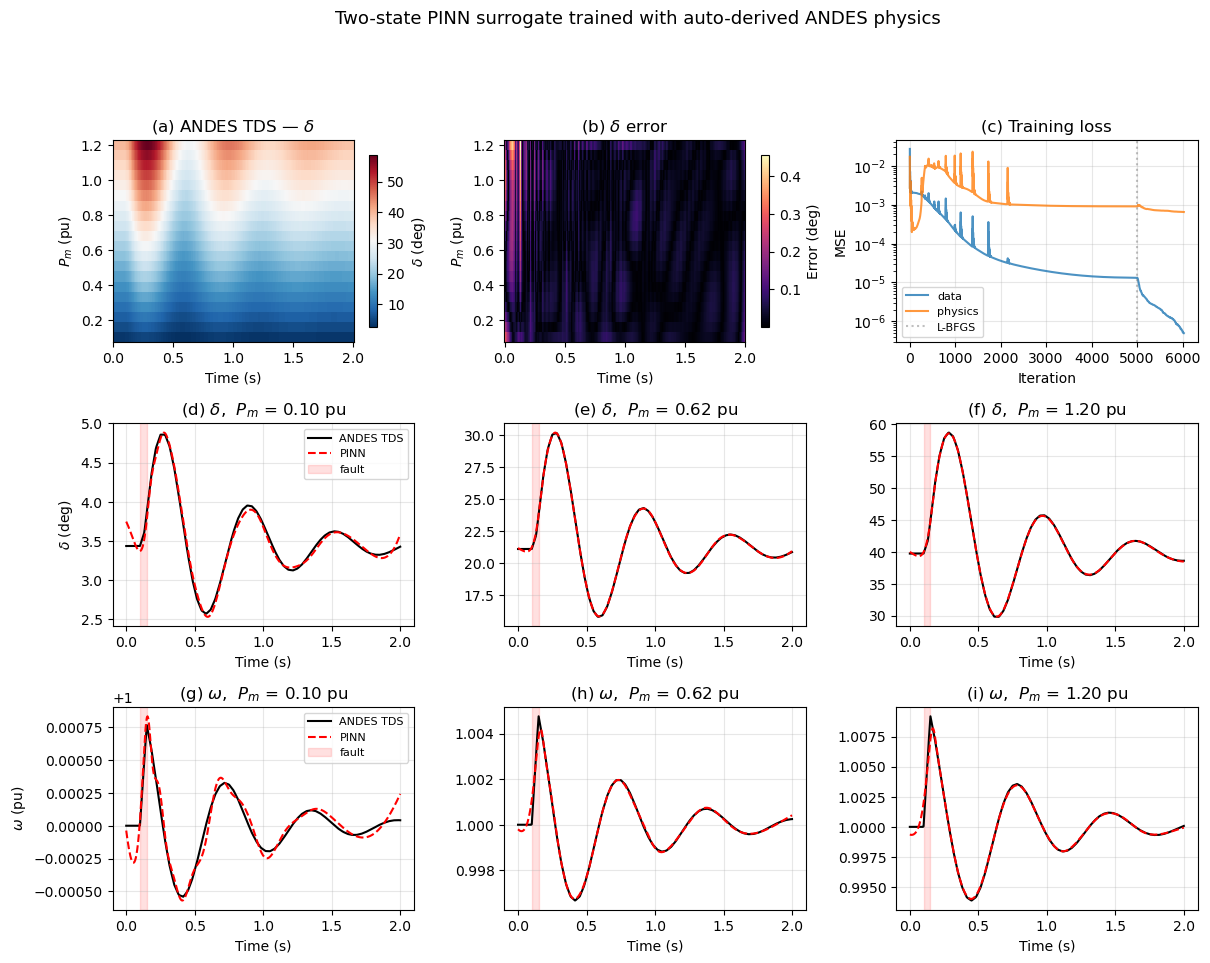

In [11]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 3, hspace=0.40, wspace=0.30)

Pm_g2, T_g2 = np.meshgrid(Pm_vec, t_vec, indexing="ij")

# ── Row 1: surfaces and loss ──
ax0 = fig.add_subplot(gs[0, 0])
c0 = ax0.pcolormesh(T_g2, Pm_g2, np.rad2deg(usol_delta),
                     shading="auto", cmap="RdBu_r")
ax0.set_xlabel("Time (s)")
ax0.set_ylabel("$P_m$ (pu)")
ax0.set_title("(a) ANDES TDS — $\\delta$")
fig.colorbar(c0, ax=ax0, label="$\\delta$ (deg)", shrink=0.85)

ax1 = fig.add_subplot(gs[0, 1])
c1 = ax1.pcolormesh(T_g2, Pm_g2, np.rad2deg(err_delta),
                     shading="auto", cmap="magma")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("$P_m$ (pu)")
ax1.set_title("(b) $\\delta$ error")
fig.colorbar(c1, ax=ax1, label="Error (deg)", shrink=0.85)

ax2 = fig.add_subplot(gs[0, 2])
ax2.semilogy(hist["data"], alpha=0.8, label="data", color="C0")
ax2.semilogy(hist["phys"], alpha=0.8, label="physics", color="C1")
ax2.axvline(ADAM_EPOCHS, color="gray", ls=":", alpha=0.5, label="L-BFGS")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("MSE")
ax2.set_title("(c) Training loss")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Row 2: delta trajectory slices ──
slice_idx = np.linspace(0, len(Pm_vec) - 1, 3, dtype=int)
for j, si in enumerate(slice_idx):
    ax = fig.add_subplot(gs[1, j])
    ax.plot(t_vec, np.rad2deg(usol_delta[si]), "k-", lw=1.5, label="ANDES TDS")
    ax.plot(t_vec, np.rad2deg(pred_delta[si]), "r--", lw=1.5, label="PINN")
    ax.axvspan(0.1, 0.15, color="red", alpha=0.12,
               label="fault" if j == 0 else None)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"({chr(100+j)}) $\\delta$,  $P_m$ = {Pm_vec[si]:.2f} pu")
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("$\\delta$ (deg)")
        ax.legend(fontsize=8)

# ── Row 3: omega trajectory slices ──
for j, si in enumerate(slice_idx):
    ax = fig.add_subplot(gs[2, j])
    ax.plot(t_vec, usol_omega[si], "k-", lw=1.5, label="ANDES TDS")
    ax.plot(t_vec, pred_omega[si], "r--", lw=1.5, label="PINN")
    ax.axvspan(0.1, 0.15, color="red", alpha=0.12,
               label="fault" if j == 0 else None)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"({chr(103+j)}) $\\omega$,  $P_m$ = {Pm_vec[si]:.2f} pu")
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("$\\omega$ (pu)")
        ax.legend(fontsize=8)

fig.suptitle(
    "Two-state PINN surrogate trained with auto-derived ANDES physics",
    fontsize=13, y=1.01,
)
plt.show()

The two-state PINN achieves sub-degree accuracy for $\delta$ and
sub-0.002 pu accuracy for $\omega$ across the full operating range,
without any hand-coded physics. Both first-order ODEs from ANDES are
enforced directly as the physics loss. The error is concentrated near
the fault window where the ODE residuals are not enforced.

This pipeline generalizes to any ANDES model: calling `prepare()` on
a higher-order machine (e.g., GENROU with multiple differential states)
produces a larger set of symbolic equations that can be processed
through the same elimination and lambdification steps.

## Extend This Example

- **Higher-order models**: replace GENCLS with GENROU to capture
  sub-transient dynamics and flux-decay effects in the surrogate.
- **Larger networks**: parameterize the PINN over load levels or
  line impedances on multi-machine systems.
- **Fast contingency screening**: once trained, the surrogate
  evaluates orders of magnitude faster than TDS, enabling
  real-time stability assessment.
- **Reinforcement learning**: combine the surrogate with an RL agent
  for control design; see the
  [RL Oscillation Damping on SMIB](smib-oscillation) gallery example.

In [12]:
!andes misc -C

No output file found in the working directory.
